# [Step 6 - RecursiveCharacterTextSplitter] The sensible default

**MLCourse - Agentic AI - Module 06: Chunking Strategies**

> Stage in the capstone: stage 2 CHUNK: chunk quality decides retrieval accuracy in the capstone.

### What you'll learn

- the separator hierarchy `["\n\n", "\n", " ", ""]` and HOW the recursion
  descends only where it must
- `length_function=len` and how to swap the yardstick
- a boundary-quality comparison against notebook 01 on the SAME slice
- why 'the default' earns its status - and the trade it quietly makes

---

In [1]:
# =====================================================================
# CELL 1 - SHARED SETUP: imports, track discovery, download-once cache
# =====================================================================

# --- Standard library -------------------------------------------------
import os                      # file-system odds and ends
import urllib.request          # polite HTTP fetching
from pathlib import Path       # object-oriented filesystem paths

# --- Lesson-specific imports ------------------------------------------
import matplotlib.pyplot as plt                                  # histograms
from langchain_community.document_loaders import TextLoader      # alice source
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,   # today's hero
    CharacterTextSplitter,            # yesterday's baseline, for comparison
)

# ---------------------------------------------------------------------
# TRACK WALKER - resolve 03_agentic_ai by walking upward from cwd.
# ---------------------------------------------------------------------
def _find_track(start: Path) -> Path:
    """Return the absolute path of the 03_agentic_ai track root."""
    for candidate in (start, *start.parents):
        hit = candidate / "03_agentic_ai"
        if hit.is_dir():
            return hit.resolve()
    raise FileNotFoundError(
        f"No directory named 03_agentic_ai found above {start} - "
        "run this notebook from somewhere inside the MLCourse repo."
    )

TRACK = _find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# DOWNLOAD-ONCE HELPERS - fetch once, cache under DATA, reuse forever.
# ---------------------------------------------------------------------
def get_bytes(fname: str, url: str) -> bytes:
    """Return the file's bytes, downloading only on the very first call."""
    target = DATA / fname
    if target.exists() and target.stat().st_size > 0:
        payload = target.read_bytes()
        print(f"[cache] {fname}: {len(payload):,} bytes")
        return payload
    print(f"[fetch] {url}")
    request = urllib.request.Request(url, headers={"User-Agent": "MLCourse/1.0"})
    with urllib.request.urlopen(request, timeout=60) as response:
        payload = response.read()
    target.write_bytes(payload)
    print(f"[saved] {fname}: {len(payload):,} bytes")
    return payload

# Matplotlib inline guard (Jupyter-only API wrapped for script safety).
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# =====================================================================
# ANALYSIS TOOLBOX - identical to notebook 01 for comparability.
# =====================================================================
def to_ascii(text: str) -> str:
    """Console-safe view of book text: curly glyphs become '?'."""
    return text.encode("ascii", errors="replace").decode("ascii")

_CURLY = {"\u2019": "'", "\u201d": '"', "\u201c": '"', "\u2018": "'"}
SENTENCE_ENDS = tuple(".!?\"')")

def ends_naturally(chunk: str) -> bool:
    """Heuristic: a CLEAN chunk tail ends in sentence-final punctuation."""
    tail = chunk.rstrip()
    if not tail:
        return True
    tail = "".join(_CURLY.get(ch, ch) for ch in tail[-3:])
    return tail.endswith(SENTENCE_ENDS)

def cut_report(chunks):
    """Return (offending chunks, percent cut mid-sentence)."""
    bad = [c for c in chunks if not ends_naturally(c)]
    pct = 100.0 * len(bad) / max(len(chunks), 1)
    return bad, pct

def describe_sizes(chunks, label):
    """Print min/mean/max character sizes; return the size list."""
    sizes = [len(c) for c in chunks]
    mean = sum(sizes) / max(len(sizes), 1)
    print(f"{label}: {len(chunks)} chunks | "
          f"min={min(sizes)} mean={mean:.0f} max={max(sizes)} chars")
    return sizes

def plot_hist(sizes, title):
    plt.figure(figsize=(8, 3))
    plt.hist(sizes, bins=30, color="#4c72b0", edgecolor="white")
    plt.title(title)
    plt.xlabel("chunk size (characters)")
    plt.ylabel("number of chunks")
    plt.tight_layout()
    plt.show()

def boundary_metrics(label, chunks):
    """One comparable line per strategy: n / mean / max / cut rate."""
    sizes = [len(c) for c in chunks]
    _, pct = cut_report(chunks)
    mean = sum(sizes) / max(len(sizes), 1)
    print(f"{label:<34} n={len(chunks):>4}  mean={mean:>6.0f}  "
          f"max={max(sizes):>5}  mid_sentence_cuts={pct:>5.1f}%")

C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_71368\105530600.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader      # alice source


### 1. WHAT changes: many separators, tried coarse-to-fine

Yesterday's splitter knew ONE separator and had no plan B. Today's tries
them IN ORDER, recursing into whatever still does not fit:

```text
separators = ["\n\n",  "\n",  " ",  ""]
              paragraphs lines spaces chars     <- coarse ........ fine

while a piece exceeds chunk_size:
    take the FIRST separator in the list
    split THAT piece with it
    repack the fragments (same merge + overlap rules as before)
```

Consequences worth internalizing:

- a paragraph that fits stays WHOLE (level-0 success);
- an oversized paragraph is retried at line level, then word level - so the
  hard cap `chunk_size` is actually ENFORCED (no more 980-char warnings);
- `length_function=len` defines 'length'. Swap it for a token counter and
  the same machinery obeys a token budget (notebook 03 does precisely that).

**Pro-tip:** this is the DEFAULT splitter across LangChain tutorials for a
reason - it degrades gracefully instead of failing loudly.

### 2. Watch the hierarchy fire - tiny toy trace

A 3-line synthetic string (fine INSIDE theory sections!) lets us watch the
descent level by level. This mirrors the algorithm conceptually; the real
implementation additionally merges fragments with overlap.

In [2]:
toy = ("Alpha paragraph line.\n\n"
       "Beta paragraph line one\nline two\nline three.\n\n"
       "Gamma end.")
SEPS = ["\n\n", "\n", " ", ""]
LIMIT = 30

pieces = [toy]
print(f"start: 1 piece of {len(toy)} chars, LIMIT={LIMIT}")
for level, sep in enumerate(SEPS):
    oversized = [p for p in pieces if len(p) > LIMIT]
    if not oversized:
        print(f"level {level} sep={sep!r}: nothing oversized - done.")
        break
    print(f"level {level} sep={sep!r}: {len(oversized)} oversized -> descend")
    descended = []
    for p in pieces:
        if len(p) <= LIMIT:
            descended.append(p)              # fits: leave untouched
        elif sep:
            descended.extend(q for q in p.split(sep) if q)
        else:
            descended.extend(list(p))        # last resort: characters
    pieces = descended

print(f"\nafter descent: {len(pieces)} pieces, "
      f"largest={max(len(p) for p in pieces)} chars (<= LIMIT enforced)")

start: 1 piece of 79 chars, LIMIT=30
level 0 sep='\n\n': 1 oversized -> descend
level 1 sep='\n': 1 oversized -> descend
level 2 sep=' ': nothing oversized - done.

after descent: 5 pieces, largest=23 chars (<= LIMIT enforced)


### 3. Head-to-head on the SAME slice as notebook 01

Fair fight: identical input (`text[:8000]`), identical targets
(`chunk_size=500`, `chunk_overlap=100`). One metric line each.

In [3]:
get_bytes("alice.txt", "https://www.gutenberg.org/files/11/11-0.txt")
alice_docs = TextLoader(str(DATA / "alice.txt"), encoding="utf-8").load()
text = alice_docs[0].page_content
slice_8000 = text[:8000]

char_chunks = CharacterTextSplitter(separator="\n\n", chunk_size=500,
                                    chunk_overlap=100).split_text(slice_8000)
rec_chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100,
                                            length_function=len,
                                            ).split_text(slice_8000)

print(f"{'strategy':<34} {'n':>4}  {'mean':>6}  {'max':>5}  metric")
boundary_metrics("character (\\n\\n only)", char_chunks)
boundary_metrics("recursive (hierarchy)", rec_chunks)

Created a chunk of size 739, which is longer than the specified 500


Created a chunk of size 715, which is longer than the specified 500


Created a chunk of size 706, which is longer than the specified 500


Created a chunk of size 684, which is longer than the specified 500


Created a chunk of size 980, which is longer than the specified 500


Created a chunk of size 578, which is longer than the specified 500


Created a chunk of size 558, which is longer than the specified 500


Created a chunk of size 719, which is longer than the specified 500


[cache] alice.txt: 151,191 bytes
strategy                              n    mean    max  metric
character (\n\n only)              n=  16  mean=   498  max=  980  mid_sentence_cuts= 18.8%
recursive (hierarchy)              n=  25  mean=   344  max=  494  mid_sentence_cuts= 48.0%


Read the numbers like a tutor would:

- recursive NEVER overshoots the 500 cap (yesterday's max was ~980);
- the price: recursive packs multiple paragraphs per chunk, so it must
  sometimes cut INSIDE a paragraph - hence a HIGHER mid-sentence rate than
  pure paragraph splitting;
- character splitting kept paragraph purity but lost size discipline.

Neither is 'wrong': they optimize different promises. Size discipline is
usually the better promise for RAG budgets - which is why recursive wins
the default crown.

recursive(500, 100) full novel: 411 chunks | min=26 mean=375 max=498 chars


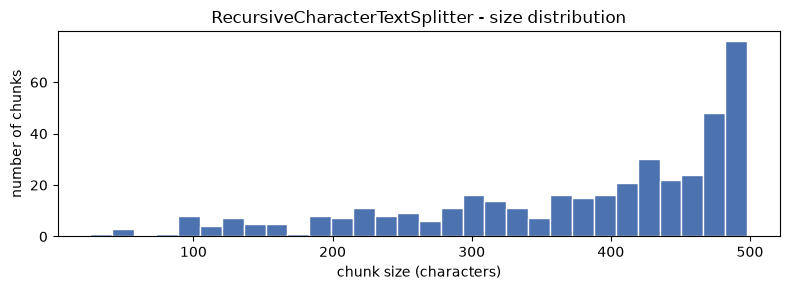


mid-sentence cut rate : 18.5%

--- offending chunk tail ---
'erland\n\nby Lewis Carroll\n\nTHE MILLENNIUM FULCRUM EDITION 3.0\n\nContents'

--- offending chunk tail ---
'\n CHAPTER XI.    Who Stole the Tarts?\n CHAPTER XII.   Alice?s Evidence'


In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100,
                                        ).split_text(text)
sizes = describe_sizes(chunks, "recursive(500, 100) full novel")
plot_hist(sizes, "RecursiveCharacterTextSplitter - size distribution")

bad, pct = cut_report(chunks)
print(f"\nmid-sentence cut rate : {pct:.1f}%")
for culprit in bad[:2]:
    print("\n--- offending chunk tail ---")
    print(repr(to_ascii(culprit[-70:])))

### 4. Swapping the yardstick: `length_function`

Length is whatever you measure. Words instead of chars (target 90 words,
overlap 15) produces a DIFFERENT segmentation of the same slice - handy
when characters correlate poorly with meaning (URLs, code, CJK scripts).

In [5]:
word_chunks = RecursiveCharacterTextSplitter(
    chunk_size=90, chunk_overlap=15,
    length_function=lambda s: len(s.split()),   # <-- the whole trick
).split_text(slice_8000)

boundary_metrics("recursive 500 chars", rec_chunks)
boundary_metrics("recursive 90 WORDS", word_chunks)
print("(same 8000-char slice; different yardstick, different atoms)")

recursive 500 chars                n=  25  mean=   344  max=  494  mid_sentence_cuts= 48.0%
recursive 90 WORDS                 n=  25  mean=   349  max=  615  mid_sentence_cuts= 48.0%
(same 8000-char slice; different yardstick, different atoms)


### Takeaway

**RecursiveCharacterTextSplitter = 'paragraphs first, lines second, words
third, characters last - and never exceed the cap.' It trades a little
boundary purity for guaranteed size discipline, which is exactly the
trade most RAG pipelines want. Start here; specialize only with a reason.**

### Summary

- The hierarchy fired visibly on the toy trace: oversized pieces alone
  descended to finer separators; fitting pieces stayed whole.
- Same-slice comparison: recursive enforced max<=~500 where character hit
  ~980, at the cost of a somewhat higher mid-sentence cut rate.
- `length_function` swaps the yardstick - characters, words, later tokens -
  without touching the algorithm.
- Full-novel run gave a tight unimodal size histogram: predictable chunks,
  predictable costs, predictable prompts.